In [19]:
#Reading iOS csv:
import pandas as pd
android_data = pd.read_pickle("Processed_Data/android_data.pkl")

**Android Preprocessing**

In [20]:
#Preparing dataset for analysis:
#Select relevant columns for analysis:
y = android_data['stress']
X = android_data.drop(columns=['stress', 'uid', 'day'])  # Drop target, ID columns, and date
print("Final feature set columns:", X.columns)
print("Final feature set shape:", X.shape)  

Final feature set columns: Index(['pam', 'phq4-1', 'phq4-2', 'phq4-3', 'phq4-4', 'phq4_resp_mean',
       'phq4_resp_median', 'phq4_score', 'social_level', 'sse3-1',
       ...
       'sleep_heathkit_dur', 'gender', 'race_alaskan native/white',
       'race_american indian/alaska native', 'race_american indian/white',
       'race_asian', 'race_black', 'race_more than one', 'race_other/hispanic',
       'race_white'],
      dtype='str', length=183)
Final feature set shape: (7256, 183)


In [21]:
#Print out all of the features that are empty due to lack of collection for Android devices:
empty_cols = X.columns[X.isna().all()]
print(empty_cols)

Index(['other_playing_duration_ep_0', 'other_playing_duration_ep_1',
       'other_playing_duration_ep_2', 'other_playing_duration_ep_3',
       'other_playing_num_ep_0', 'other_playing_num_ep_1',
       'other_playing_num_ep_2', 'other_playing_num_ep_3',
       'sleep_heathkit_dur'],
      dtype='str')


In [22]:
# android missing features are all NaN, so we can drop those columns before modeling:
X = X.dropna(axis=1, how='all')

In [23]:
#Splitting data into test and train sets to prevent data leakage:
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold

#Column that identifies groups (participants):
group_col = 'uid'

#80/20 training testing split, with one testing group:
gss = GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=ios_data[group_col]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train = ios_data[group_col].iloc[train_idx]

#Checking stress label distribution to ensure the groups are stratified:
print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest distribution:")
print(y_test.value_counts(normalize=True))

Train distribution:
stress
2.0    0.345873
3.0    0.253521
1.0    0.253165
4.0    0.110537
5.0    0.036905
Name: proportion, dtype: float64

Test distribution:
stress
3.0    0.295689
2.0    0.282332
1.0    0.239830
4.0    0.100182
5.0    0.081967
Name: proportion, dtype: float64


In [24]:
#Checking to see how many unique stress levels each participant has in the merged dataset:
android_data.groupby("uid")["stress"].nunique().value_counts()

stress
5    23
4     9
3     1
Name: count, dtype: int64

In [25]:
#Splitting training set into groups with StratifiedGroupKFold:
gkf = StratifiedGroupKFold(n_splits=5)

**Feature Selection**

In [26]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

#Cross-validation loop for ElasticNet regression with median imputation and standardization:

mae_scores = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    #Pipeline with median imputation and ElasticNet regression:
    EN_model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("elasticnet", ElasticNet(
            alpha=0.1,
            l1_ratio=0.3,
            max_iter=5000,
            random_state=42)
        )
    ])
    
    EN_model.fit(X_tr, y_tr)
    
    preds = EN_model.predict(X_val)
    mae_scores.append(mean_absolute_error(y_val, preds))

print("ElasticNet CV MAE:", np.mean(mae_scores))
    

ElasticNet CV MAE: 0.6716165574036503


In [27]:
#Extracting feature importance from the ElasticNet model:
elastic = EN_model.named_steps["elasticnet"]
coefs = elastic.coef_
feature_names = X_train.columns

#Create a dataframe to display feature names and their corresponding coefficients:
EN_importance = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefs
})

EN_importance["abs_coef"] = EN_importance["coefficient"].abs()
EN_importance = EN_importance.sort_values(by="abs_coef", ascending=False)

print(EN_importance.head(20))

                          feature  coefficient  abs_coef
9                          sse3-1     0.209315  0.209315
0                             pam    -0.179517  0.179517
11                         sse3-3    -0.158568  0.158568
12                         sse3-4    -0.114137  0.114137
1                          phq4-1     0.091417  0.091417
7                      phq4_score     0.044819  0.044819
84                light_mean_ep_3     0.042543  0.042543
116             loc_self_dorm_dur     0.041365  0.041365
47             audio_amp_std_ep_2    -0.033791  0.033791
36                 act_still_ep_3     0.030608  0.030608
4                          phq4-4     0.028152  0.028152
2                          phq4-2     0.026195  0.026195
43            audio_amp_mean_ep_2    -0.025206  0.025206
97                   loc_food_dur     0.022506  0.022506
17            act_in_vehicle_ep_0    -0.019774  0.019774
170                    race_black     0.019137  0.019137
165                        gend

In [28]:
#List of non-zero coefficients (indicate features that contribute to the model's predictions):
selected_features = EN_importance[EN_importance["coefficient"] != 0]
print(selected_features)

                          feature  coefficient  abs_coef
9                          sse3-1     0.209315  0.209315
0                             pam    -0.179517  0.179517
11                         sse3-3    -0.158568  0.158568
12                         sse3-4    -0.114137  0.114137
1                          phq4-1     0.091417  0.091417
7                      phq4_score     0.044819  0.044819
84                light_mean_ep_3     0.042543  0.042543
116             loc_self_dorm_dur     0.041365  0.041365
47             audio_amp_std_ep_2    -0.033791  0.033791
36                 act_still_ep_3     0.030608  0.030608
4                          phq4-4     0.028152  0.028152
2                          phq4-2     0.026195  0.026195
43            audio_amp_mean_ep_2    -0.025206  0.025206
97                   loc_food_dur     0.022506  0.022506
17            act_in_vehicle_ep_0    -0.019774  0.019774
170                    race_black     0.019137  0.019137
165                        gend

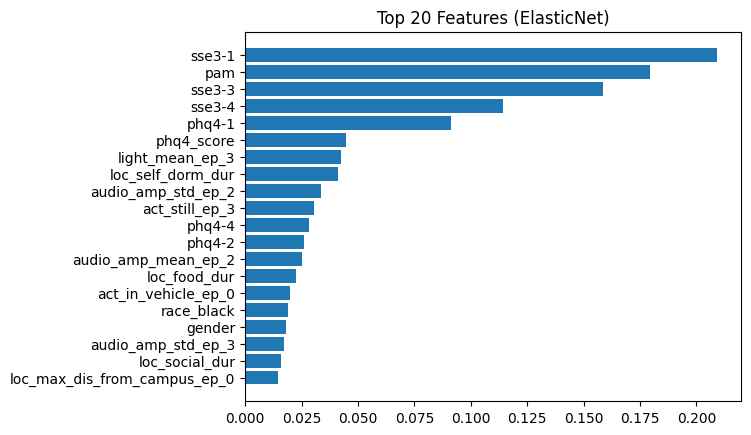

In [29]:
import matplotlib.pyplot as plt

#Visualize the top 20 most important features based on absolute coefficient values:
top = EN_importance.head(20)
plt.figure()
plt.barh(top["feature"], top["abs_coef"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (ElasticNet)")
plt.show()

In [30]:
#XGBoost regression with median imputation and standardization:
from xgboost import XGBRegressor

mae_scores_xgb = []

for train_idx, val_idx in gkf.split(X_train, y_train, groups=groups_train):
    
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    XGBR_model = XGBRegressor(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    XGBR_model.fit(X_tr.values, y_tr.values)
    
    preds = XGBR_model.predict(X_val.values)
    mae_scores_xgb.append(mean_absolute_error(y_val, preds))

print("XGBoost CV MAE:", np.mean(mae_scores_xgb))

XGBoost CV MAE: 0.6796263123654703


In [31]:
#Final XGBoost model trained on the entire training set for feature importance:
final_XGBR_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

final_XGBR_model.fit(X_train.values, y_train.values)

#Feature importance from XGBoost model:
xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": XGBR_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(by="importance", ascending=False)

xgb_importance.head(20)

,feature,importance
12,sse3-4,0.097321
11,sse3-3,0.077485
9,sse3-1,0.043086
7,phq4_score,0.042076
0,pam,0.025392
17,act_in_vehicle_ep_0,0.021156
4,phq4-4,0.014697
113,loc_self_dorm_audio_voice,0.010352
127,loc_social_unlock_num,0.010250
173,race_white,0.009932


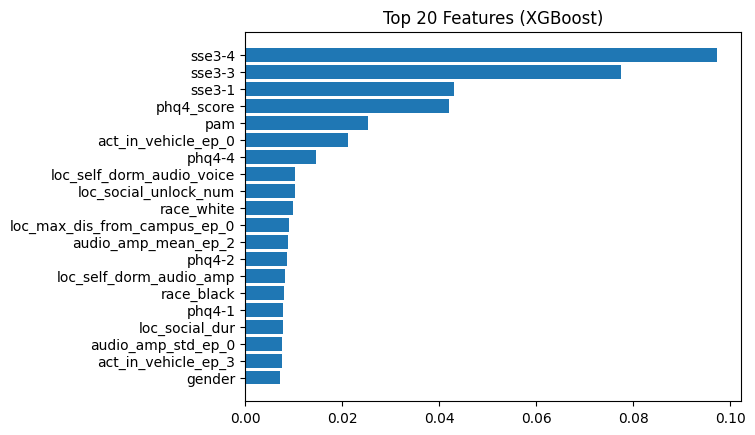

In [32]:
#Visualize the top 20 most important features from the XGBoost model:
top = xgb_importance.head(20)

plt.figure()
plt.barh(top["feature"], top["importance"])
plt.gca().invert_yaxis()
plt.title("Top 20 Features (XGBoost)")
plt.show()

In [40]:
#Merge results from ElasticNet and XGBoost to see which features are important in both models:
android_merged_importance = pd.merge(
    EN_importance[["feature", "coefficient"]],
    xgb_importance[["feature", "importance"]],
    on="feature",
    how="inner"
)

#Normalize importance values for better comparison:
android_merged_importance["coef_norm"] = android_merged_importance["coefficient"].abs() / android_merged_importance["coefficient"].abs().max()
android_merged_importance["xgb_norm"] = android_merged_importance["importance"] / android_merged_importance["importance"].max()

#Create a combined importance score by averaging the normalized values from both models:
android_merged_importance["combined_score"] = (android_merged_importance["coef_norm"] + android_merged_importance["xgb_norm"]) / 2

#Keep only relevant columns and sort by combined score:
android_merged_importance = android_merged_importance[["feature", "coef_norm", "xgb_norm", "combined_score"]]
android_merged_importance = android_merged_importance.sort_values(by="combined_score", ascending=False)

print(android_merged_importance.tail(50))

                                feature  coef_norm  xgb_norm  combined_score
166               call_in_duration_ep_3        0.0  0.035300        0.017650
68                     sms_out_num_ep_3        0.0  0.035172        0.017586
120                      phq4_resp_mean        0.0  0.034335        0.017167
74                      unlock_num_ep_1        0.0  0.034166        0.017083
132                    act_on_bike_ep_2        0.0  0.033974        0.016987
162                    audio_voice_ep_3        0.0  0.033520        0.016760
102                      act_still_ep_0        0.0  0.033466        0.016733
135                audio_convo_num_ep_1        0.0  0.033180        0.016590
103                      act_still_ep_1        0.0  0.033128        0.016564
86                      loc_workout_dur        0.0  0.033010        0.016505
121                    phq4_resp_median        0.0  0.032583        0.016291
117                    act_on_foot_ep_2        0.0  0.032270        0.016135

In [49]:
#Selecting features that have a combined importance score above a threshold of 0.02:
android_selected_features = android_merged_importance[
    android_merged_importance["combined_score"] > 0.02
].index

print("Number of selected features:", len(android_selected_features))

Number of selected features: 106


In [50]:
X = X[selected_features]